# Exercise 1: K-Means Algorithm

You are given a dataset that contains statistics about years of work experience and its corresponding salary. The dataset can be found together with this exercise or you can download from https://www.kaggle.com/datasets/rohankayan/years-of-experience-and-salary-dataset
<br>
<br>

**The dataset comprises 2 columns as follows:**
- YearsExperience: Number of working years.
- Salary: Annual salary.

<br>

**Now, you are required to import sklearn library and find out the optimum number of clusters by following the task below.** 


### Task 1
- Load the "Salary_Data.csv" dataset and perform basic data preprocessing steps.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


import warnings
# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Ignore UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Load the dataset
df = pd.read_csv("Salary_Data.csv")


In [3]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [6]:
df.shape

(30, 2)

In [7]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [8]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

## Task 2
- Perform some basic visualization of the dataset to gain some insights from the data.

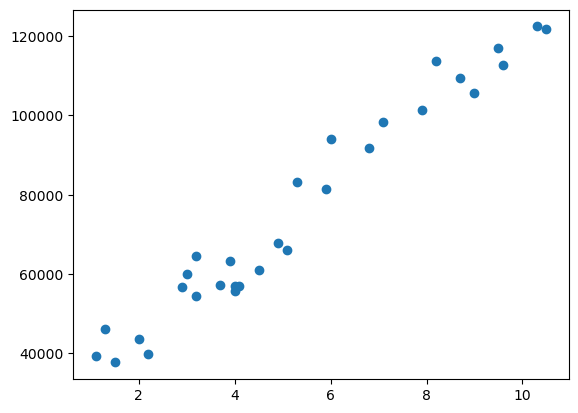

In [9]:
plt.scatter(df['YearsExperience'], df['Salary'])

In [10]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


## Task 3
- Scale the features using the standard scaler from sklearn.

In [14]:
# Split the dataset into features
X = df.iloc[:, :]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the training data
scaler.fit(X)

# Transform the training data
X_scaled = scaler.transform(X)

# Reattach column names and convert back to pd
scaled_df = pd.DataFrame(X_scaled, columns=df.columns[:])
scaled_df

,YearsExperience,Salary
0,-1.510053,-1.360113
1,-1.438373,-1.105527
2,-1.366693,-1.419919
3,-1.187494,-1.204957
4,-1.115814,-1.339781
5,-0.864935,-0.718307
6,-0.829096,-0.588158
7,-0.757416,-0.799817
8,-0.757416,-0.428810
9,-0.578216,-0.698013


## Task 4
- Determine the optimum number of clusters for this dataset using the elbow method.
- Then plot the elbow.

In [74]:
# Create a list of values for the number of clusters
k_values = range(1, 11)

# Calculate the within-cluster sum of squares (WCSS) for each value of k
wcss_list = []
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    wcss = kmeans.inertia_
    wcss_list.append(wcss)

In [92]:
wcss_list

[60.0,
 12.746903597965789,
 7.085117693476552,
 3.072932931172564,
 2.1573921184415887,
 1.5510059634033833,
 1.1314268427319747,
 0.9067981183218711,
 0.7400474916130372,
 0.6407734746940016]

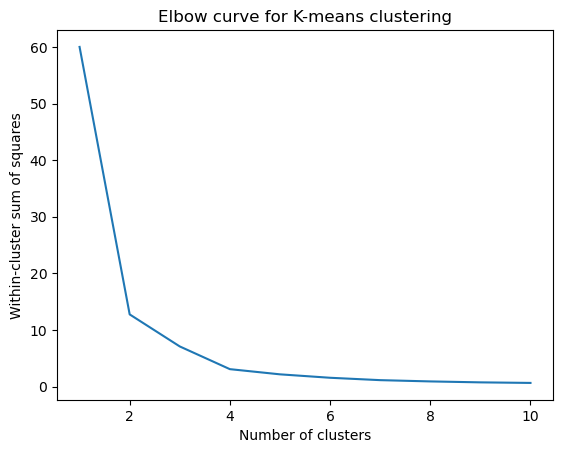

In [75]:
# Plot the elbow curve
plt.plot(k_values, wcss_list)
plt.xlabel("Number of clusters")
plt.ylabel("Within-cluster sum of squares")
plt.title("Elbow curve for K-means clustering")
plt.show()

In [76]:
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(df)
kmeans.cluster_centers_

array([[3.87500000e+00, 6.00832500e+04],
       [9.40000000e+00, 1.14670286e+05],
       [6.50000000e+00, 9.16173333e+04],
       [1.62000000e+00, 4.13390000e+04]])

In [77]:
labels = kmeans.labels_
labels

array([3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1])

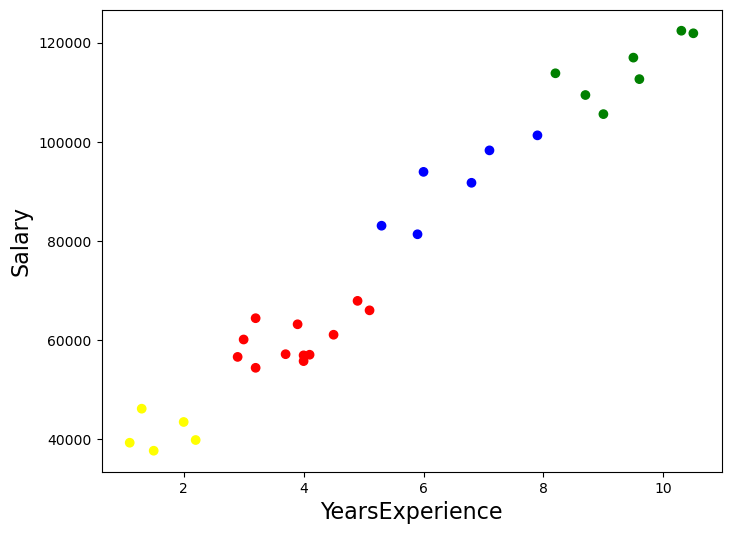

In [78]:
import matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
labels = kmeans.labels_
colors = ['red','green','blue','yellow']
plt.scatter(df['YearsExperience'], df['Salary'], c=labels,
cmap=matplotlib.colors.ListedColormap(colors))
plt.xlabel('YearsExperience', fontsize=16)
plt.ylabel('Salary', fontsize=16)
#plt.savefig("kmeans_small_dataset.jpg")
plt.show()

In [40]:
## profiling the clusters
clusterer = KMeans(n_clusters=4, random_state=10)
cluster_labels = clusterer.fit_predict(df_scaled)
cluster_labels
df['Clusters'] = cluster_labels

clus_profile = df.groupby(['Clusters'], 
                       as_index=False).mean()
clus_profile

C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Clusters,YearsExperience,Salary
0,0,3.875000,60083.25
1,1,8.977778,111363.00
2,2,1.620000,41339.00
3,3,6.000000,87532.25


In [41]:
df

,YearsExperience,Salary,Clusters
0,1.1,39343.0,2
1,1.3,46205.0,2
2,1.5,37731.0,2
3,2.0,43525.0,2
4,2.2,39891.0,2
5,2.9,56642.0,0
6,3.0,60150.0,0
7,3.2,54445.0,0
8,3.2,64445.0,0
9,3.7,57189.0,0


## Task 5
- Explain in your own words what is elbow point/curve. And what is optimum number of clusters based on the visualization plot in Task 4.

#### Answer:
The elbow method is a graphical method for determining the optimal number of clusters in a k-means clustering algorithm. It works by finding the within-cluster sum of squares (WCSS), which is the sum of the squared distances between each data point and its assigned cluster centroid. A lower WCSS indicates a better fit.

The elbow of the curve is the point where the WCSS starts to decrease slowly. This is the optimal number of clusters for the data. Hence, for the dataset above, the optimum number of cluster is 4.